## Libraries

In [1]:
!pip install -q \
  transformers \
  peft \
  huggingface_hub \
  ipywidgets

!pip install -U bitsandbytes
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.3/506.3 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 18.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 21.0.0 which is incompatible.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0

In [2]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"
import sys
import time
import torch
import numpy as np
import random
import inspect
import ipywidgets
import pandas as pd
import json
from itertools import chain
import plotly.express as px
from datetime import datetime
from torch.utils.data import Dataset, Sampler
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
from datasets import load_dataset, concatenate_datasets, Dataset, DatasetDict
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
from itertools import islice
from collections import Counter
import matplotlib.pyplot as plt
import ipywidgets as widgets
import notebook
import sys, jupyterlab_widgets
from IPython.display import display
from IPython.display import clear_output, display, update_display, DisplayHandle
from huggingface_hub import login, HfFolder, HfApi, hf_hub_download, delete_repo, list_repo_files, snapshot_download, CommitOperationDelete, create_commit
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, BitsAndBytesConfig, TrainerCallback, DataCollatorWithPadding
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:32" # Allows to split memory into pieces when allocating (normally the GPU VRAM needs a contiguous block of memory). Caps memory block size to maximum of 32 MB

## Load model & dataset

##### Login to huggingface

In [3]:
login()

### Optimal values

In [4]:
learning_rate = 7.5e-4
warmup_ratio = 0.04
lr_scheduler_type = "cosine"
lora_dropout = 0.05
weight_decay = 0.05

r=32
lora_alpha=32
target_modules=["q_proj","v_proj","down_proj","up_proj"]

gradient_accumulation_steps = 32
per_device_train_batch_size = 1
min_delta=0.1
patience=24

#### Load base model

The GPU VRAM is not sufficient for training the model. We use LoRA to make it more efficient

In [5]:
# Use only for loading new tinyllama model

# --- Tokenizer ---
tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")

# --- 4-bit quantization config (NF4 QLoRA) ---
# Tip: bfloat16 on A100/H100; float16 on T4/V100
USE_BF16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
compute_dtype = torch.bfloat16 if USE_BF16 else torch.float16
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype,
)

# --- Load base model in 4-bit ---
model = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    device_map="auto",
    quantization_config=quant_config,
)

# Prepare for k-bit LoRA training (input grads, norm cast, etc.)
model = prepare_model_for_kbit_training(model)
model.config.use_cache = False  # avoid grad checkpointing warnings during training

# --- LoRA config with your best params ---
lora_config = LoraConfig(
    r=r,
    lora_alpha=lora_alpha,
    target_modules=target_modules,
    lora_dropout=lora_dropout,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

# Apply LoRA adapters
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

trainable params: 15,319,040 || all params: 1,115,367,424 || trainable%: 1.3735


In [6]:
print(model.base_model_prefix)
print(model)

model
PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj)

#### Load fine-tuned model with LoRA adapters

In [ ]:
"""

# Load base model
base = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    load_in_8bit=True,        # 8-bit quantization
    device_map="auto"
)

# Load your previously trained LoRA adapter (set as trainable)
model = PeftModel.from_pretrained(
    base,
    "eduhuemar001/tinyllama-german-sentiment",
    is_trainable=True         # Required for continued training
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")

model.print_trainable_parameters()  # Only LoRA layers should be trainable
print(model.base_model_prefix)
print(model)

"""

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023
model
PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear8bitLt(
                (base_layer): Linear8bitLt(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
           

#### Load dataset

In [7]:
# === CONSTANTS ===
HF_DATASET_REPO_ID = "eduhuemar001/dataset-sentiment-4bit-train-v6"
HF_DATASET_REPO_ID_TEST = "eduhuemar001/dataset-sentiment-4bit-test-v6"
DATASET_FILE = "train_dataset.json"
LOCAL_DATASET_PATH = f"/content/{DATASET_FILE}"
REMOTE_DATASET_PATH = f"{DATASET_FILE}"

HF_DATASET_REPO_GERMEVAL = "eduhuemar001/sentiment-GermEval2017"
HF_DATASET_REPO_SB10K = "eduhuemar001/sentiment-SB10k"
HF_DATASET_REPO_HOLIDAYCHECK = "eduhuemar001/sentiment-holidaycheck-balanced"

TRAIN_PATH = "/content/train_dataset.json"
TEST_PATH = "/content/test_dataset.json"

api = HfApi()

# === Check if dataset already exists ===
try:
    files = list_repo_files(HF_DATASET_REPO_ID, repo_type="dataset")
    dataset_exists = REMOTE_DATASET_PATH in files
except Exception as e:
    print(f"Repo does not exist or could not be listed: {e}")
    files = []
    dataset_exists = False

if dataset_exists:
    print("Loading existing dataset from Hugging Face Hub...")

    dataset_path = hf_hub_download(
        repo_id=HF_DATASET_REPO_ID,
        filename=REMOTE_DATASET_PATH,
        repo_type="dataset",
        local_dir="/content",
        local_dir_use_symlinks=False
    )

    # Read JSON lines (not a single JSON object)
    with open(dataset_path, "r", encoding="utf-8") as f:
        dataset = [json.loads(line) for line in f if line.strip()]

else:
    print("No existing dataset found. Loading and balancing from sentiment datasets...")

    # === Load datasets ===
    ds_germeval = load_dataset(HF_DATASET_REPO_GERMEVAL, split="train")
    ds_sb10k = load_dataset(HF_DATASET_REPO_SB10K, split="train")
    ds_holidaycheck = load_dataset(HF_DATASET_REPO_HOLIDAYCHECK, split="train")

    # === Count sentiment samples ===
    combined_existing = concatenate_datasets([ds_germeval, ds_sb10k])
    counts = Counter(combined_existing["sentiment"])
    print("Before balancing:", dict(counts))

    max_count = max(counts.values())
    needed_pos = max_count - counts.get("positive", 0)
    needed_neg = max_count - counts.get("negative", 0)

    # === Add positive/negative from HolidayCheck ===
    hc_pos = ds_holidaycheck.filter(lambda x: x["sentiment"] == "positive").shuffle(seed=12345).select(range(needed_pos))
    hc_neg = ds_holidaycheck.filter(lambda x: x["sentiment"] == "negative").shuffle(seed=12345).select(range(needed_neg))

    # === Combine and shuffle ===
    combined_ds = concatenate_datasets([ds_germeval, ds_sb10k, hc_pos, hc_neg]).shuffle(seed=12345)
    final_counts = Counter(combined_ds["sentiment"])
    print("After balancing:", dict(final_counts))

    # === Train/test split ===
    split = combined_ds.train_test_split(test_size=0.2, seed=12345)
    train_ds = split["train"]
    test_ds = split["test"]

    print("\nTrain counts:", Counter(train_ds["sentiment"]))
    print("Test counts:", Counter(test_ds["sentiment"]))

    # === Save function ===
    def export_dataset(ds, path):
        json_data = []
        with open(path, "w", encoding="utf-8") as f:
            for example in ds:
                if example["review_text"] and example["sentiment"]:
                    item = {
                        "review_text": example["review_text"].strip(),
                        "sentiment": example["sentiment"].strip()
                    }
                    json.dump(item, f, ensure_ascii=False)
                    f.write("\n")
                    json_data.append(item)
        return json_data

    # === Save train/test to disk ===
    print("Saving datasets to disk...")
    dataset = export_dataset(train_ds, TRAIN_PATH)
    export_dataset(test_ds, TEST_PATH)

    # === Upload to Hugging Face Hub ===
    print("Uploading datasets to Hugging Face Hub...")

    # Upload train split
    api.create_repo(repo_id=HF_DATASET_REPO_ID, repo_type="dataset", exist_ok=True, token=True)
    api.upload_file(
        path_or_fileobj=TRAIN_PATH,
        path_in_repo="train_dataset.json",
        repo_id=HF_DATASET_REPO_ID,
        repo_type="dataset",
        commit_message="Upload sentiment train split"
    )

    # Upload test split
    api.create_repo(repo_id=HF_DATASET_REPO_ID_TEST, repo_type="dataset", exist_ok=True, token=True)
    api.upload_file(
        path_or_fileobj=TEST_PATH,
        path_in_repo="test_dataset.json",
        repo_id=HF_DATASET_REPO_ID_TEST,
        repo_type="dataset",
        commit_message="Upload sentiment test split"
    )

    print("Upload complete.")

Loading existing dataset from Hugging Face Hub...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:982: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


train_dataset.json:   0%|          | 0.00/20.6M [00:00<?, ?B/s]

## Preprocessing

#### Tokenize data

The full sentiment prompt and label are kept together. Avoid information loss from chunking (one "chunk" has variable size).

In [ ]:
print(dataset[:2])

[{'review_text': '@Airport_FRA Wenn ich, wie Ihre Sicherheits-MA es gerne hätten, dann ja auch Bahn fahren kann, würden Sie an mir kein Geld verdienen.', 'sentiment': 'neutral'}, {'review_text': 'Re: Mutterliebe Wir haben den B-Motion 4 Der ist klasse kann ich nur empfehlen �� Ich persönlich finde drei Räder nicht gut besonders wenn man mal mit Bus und Bahn fährt da ist schon der ein oder andere Wagen umgekippt :/', 'sentiment': 'neutral'}]


In [8]:
train_dataset = None

class SentimentDataset(Dataset):
    def __init__(self, dataset, tokenizer, max_length=512):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self._data = []

        # Fixed parts of the prompt
        self.instruction_prefix = (
            "### Instruction:\n"
            "Klassifiziere die Stimmung der folgenden Bewertung als 'positiv', 'neutral' oder 'negativ'.\n\n"
            "### Bewertung:\n"
        )
        self.answer_prefix = "\n\n### Antwort:\n"

        for item in dataset:
            review_text = item["review_text"].strip()
            sentiment = item["sentiment"].strip()

            # Tokenize fixed parts
            prefix_tokens = tokenizer(self.instruction_prefix, add_special_tokens=False)["input_ids"]
            review_tokens = tokenizer(review_text, add_special_tokens=False)["input_ids"]
            answer_prefix_tokens = tokenizer(self.answer_prefix, add_special_tokens=False)["input_ids"]
            label_tokens = tokenizer(sentiment, add_special_tokens=False)["input_ids"]

            # Calculate how many review tokens fit
            reserved = len(prefix_tokens) + len(answer_prefix_tokens) + len(label_tokens)
            max_review_len = self.max_length - reserved
            if max_review_len <= 0:
                continue  # skip if too long

            review_tokens = review_tokens[:max_review_len]

            # Combine all
            input_ids = prefix_tokens + review_tokens + answer_prefix_tokens + label_tokens
            labels = [-100] * (len(prefix_tokens) + len(review_tokens) + len(answer_prefix_tokens)) + label_tokens

            # Pad
            pad_len = self.max_length - len(input_ids)
            input_ids += [tokenizer.pad_token_id] * pad_len
            labels += [-100] * pad_len

            # Sanity check
            if len(input_ids) != self.max_length or len(labels) != self.max_length:
                continue

            self._data.append({
                "input_ids": torch.tensor(input_ids, dtype=torch.long),
                "labels": torch.tensor(labels, dtype=torch.long)
            })

    def __len__(self):
        return len(self._data)

    def __getitem__(self, idx):
        if isinstance(idx, list):
            # Handle a list of indices for batching
            return {
                "input_ids": torch.stack([self._data[i]["input_ids"] for i in idx]),
                "labels": torch.stack([self._data[i]["labels"] for i in idx]),
            }
        else:
            # Handle single index or slice
            return self._data[idx]

train_dataset = SentimentDataset(dataset, tokenizer, max_length=256)

Token indices sequence length is longer than the specified maximum sequence length for this model (4308 > 2048). Running this sequence through the model will result in indexing errors


In [ ]:
for i in range(3):
    print(f"\n--- Sample {i} ---")
    sample = train_dataset[i]
    ids = sample["input_ids"]
    lbls = sample["labels"]
    print("\nInput tokens:", sample["input_ids"])
    print("\nDecoded input:", tokenizer.decode(ids, skip_special_tokens=True))
    print("\nLabel tokens:", sample["labels"])
    print("\nDecoded label:", tokenizer.decode([id for id, l in zip(ids, lbls) if l != -100]))


--- Sample 0 ---

Input tokens: tensor([  835,  2799,  4080, 29901,    13, 29968,   605,   361, 10077,   406,
          762,   624,  6727,   686,   589, 24245,  1522, 16347,   686,  1620,
          525,  1066,   277,   440,   742,   525, 17821,  1705, 29915,  4461,
          525, 10052,  1926,  4286,    13,    13,  2277, 29937,  1522, 16347,
          686, 29901,    13,   732, 29909,   381,   637, 29918, 29943,  4717,
          399,  2108,  7975, 29892,  4031,   306, 16720,   317, 12805, 25714,
        29899,  1529,   831,  9814,   484,   298, 29322, 29892,  7885, 12337,
         2907, 15131,   285, 21446,  9083, 29892, 21770,  1145,  4073,   385,
        10078, 23943,   402,  2495, 12868, 12980, 29889, 29871,    13,    13,
         2277, 29937,  5459, 17572, 29901,    13, 21104,     2,     2,     2,
            2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
            2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
            2,     2,     2,   

## Logging & Plotting

#### Load previous logs

In [9]:
HF_LOG_REPO_ID = "eduhuemar001/tinyllama-german-sentiment-4bit-training-v6"
LOG_SUBDIR = "logs"

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
logfile_name = f"loss_log_{timestamp}.csv"
remote_log_path = f"{LOG_SUBDIR}/{logfile_name}"
local_log_path = f"/content/{logfile_name}"

api = HfApi()
total_logged_steps = 0
all_logs = []

for file in list_repo_files(HF_LOG_REPO_ID, repo_type="model"):
    if file.startswith(LOG_SUBDIR) and file.endswith(".csv"):
        try:
            local_path = hf_hub_download(
                repo_id=HF_LOG_REPO_ID,
                repo_type="model",
                filename=file,
                local_dir="/content",
                local_dir_use_symlinks=False
            )
            df = pd.read_csv(local_path)
            all_logs.append(df)
            if not df.empty:
                step_max = df["global_step"].max()
                if step_max > total_logged_steps:
                    total_logged_steps = step_max
        except:
            print(f"Failed to load: {file}")

loss_log_20251019_1926.csv: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:982: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


loss_log_20251019_2351.csv:   0%|          | 0.00/858 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:982: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


loss_log_20251020_0052.csv: 0.00B [00:00, ?B/s]

In [ ]:
print(total_logged_steps)

0


#### Create logging callback

In [10]:
class LossLoggingCallback(TrainerCallback):
    def __init__(self, local_path, remote_path, repo_id, step_offset=0, flush_every_n_steps=50):
        self.local_path = local_path
        self.remote_path = remote_path
        self.repo_id = repo_id
        self.step_offset = step_offset
        self.flush_every_n_steps = flush_every_n_steps
        self.losses = []
        self.initial_global_step = None

    def on_train_begin(self, args, state, control, **kwargs):
        # Initialize at the very start of training
        if self.initial_global_step is None:
            self.initial_global_step = state.global_step
            print(f"[Init] Training starts at global_step: {self.initial_global_step}")

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            step = state.global_step
            adjusted_step = self.step_offset + (step - self.initial_global_step)
            loss = logs["loss"]
            self.losses.append((adjusted_step, loss))

            if len(self.losses) % self.flush_every_n_steps == 0:
                self._flush_log(adjusted_step)

    def on_save(self, args, state, control, **kwargs):
        if self.losses:
            last_logged_step = self.step_offset + (state.global_step - self.initial_global_step)
            self._flush_log(last_logged_step)

    def on_train_end(self, args, state, control, **kwargs):
        if self.losses:
            final_step = self.step_offset + (state.global_step - self.initial_global_step)
            self._flush_log(final_step)

    def _flush_log(self, current_step):
        try:
            df = pd.DataFrame(self.losses, columns=["global_step", "training_loss"])
            df.to_csv(self.local_path, index=False)

            api = HfApi()
            api.upload_file(
                path_or_fileobj=self.local_path,
                path_in_repo=self.remote_path,
                repo_id=self.repo_id,
                repo_type="model",
                commit_message=f"Auto-flushed loss log at step {current_step}"
            )
            print(f"Loss log flushed to Hugging Face at step {current_step}")
        except Exception as e:
            print(f"Failed to upload loss log at step {current_step}: {e}")

#### Create real-time plotting callback

In [11]:
class LiveLossPlotCallback(TrainerCallback):
    def __init__(self, base_logs=None, step_offset=0, gap_threshold=500):
        self.df_history = pd.concat(base_logs, ignore_index=True) if base_logs else pd.DataFrame(columns=["global_step", "training_loss"])
        self.step_offset = step_offset
        self.gap_threshold = gap_threshold
        self.new_data = []
        self.display_handle = None
        self.initialized = False
        self.initial_global_step = None  # Will be set in on_train_begin

    def on_train_begin(self, args, state, control, **kwargs):
        # Ensure to capture the actual starting global step
        if self.initial_global_step is None:
            self.initial_global_step = state.global_step
            print(f"[LivePlot Init] Training starts at global_step: {self.initial_global_step}")

    def _render_plots(self):
        if not self.new_data:
            return

        # Corrected Cumulative Plot Data
        adjusted_cumulative_data = [
            ((s - self.initial_global_step) + self.step_offset, l) for s, l in self.new_data
        ]

        df_all = pd.concat([
            self.df_history,
            pd.DataFrame(adjusted_cumulative_data, columns=["global_step", "training_loss"])
        ], ignore_index=True)

        df_all.sort_values("global_step", inplace=True)

        # Insert NaNs for step gaps
        step_diff = df_all["global_step"].diff()
        gap_indices = step_diff[step_diff > self.gap_threshold].index
        for idx in gap_indices[::-1]:
            df_all = pd.concat([
                df_all.iloc[:idx],
                pd.DataFrame({"global_step": [None], "training_loss": [None]}),
                df_all.iloc[idx:]
            ], ignore_index=True)

        # Current session: normalize steps to start from 0
        df_current = pd.DataFrame(self.new_data, columns=["step", "training_loss"])
        df_current["step"] = df_current["step"] - self.initial_global_step  # Correct relative step

        # Plot both graphs
        fig, (ax_all, ax_current) = plt.subplots(2, 1, figsize=(10, 8))

        # Cumulative Plot
        ax_all.plot(df_all["global_step"], df_all["training_loss"], marker=',', linestyle='-', label="Cumulative Loss")
        ax_all.set_xlabel("Global Step")
        ax_all.set_ylabel("Loss")
        ax_all.set_title("Live Training Loss (All Trainings)")
        ax_all.grid(True)

        # Current Run Plot
        ax_current.plot(df_current["step"], df_current["training_loss"], marker=',', linestyle='-', color='orange', label="Current Session")
        ax_current.set_xlabel("Step")
        ax_current.set_ylabel("Loss")
        ax_current.set_title("Live Training Loss (Current Training)")
        ax_current.grid(True)

        plt.tight_layout()

        if not self.initialized:
            self.display_handle = display(fig, display_id=True)
            self.initialized = True
        else:
            update_display(fig, display_id=self.display_handle.display_id)

        plt.close(fig)

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            step = state.global_step
            loss = logs["loss"]

            self.new_data.append((step, loss))
            self._render_plots()

### Create early stopping callback

In [12]:
"""
class TrainLossEarlyStop(TrainerCallback):
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best = None
        self.bad_count = 0

    def on_log(self, args, state, control, logs=None, **kwargs):
        # HF logs training loss at your logging_steps as "loss"
        if not logs or "loss" not in logs:
            return control

        cur = float(logs["loss"])
        if self.best is None or cur < self.best - self.min_delta:
            self.best = cur
            self.bad_count = 0
        else:
            self.bad_count += 1

        if (self.bad_count >= self.patience and self.best < 0.4):
            control.should_training_stop = True
            print(f"[EarlyStop] no train-loss improvement for {self.patience} logs "
                  f"(best={self.best:.4f}, last={cur:.4f}).")

        return control
"""

class TrainLossEarlyStop(TrainerCallback):
    def __init__(self, repo_id: str, subdir: str = "best_lora", min_delta: float = 1e-4,
                 patience: int = 1, local_dir: str = "tinyllama-german-lora"):
        self.repo_id = repo_id
        self.subdir = subdir.strip("/")
        self.min_delta = min_delta
        self.patience = patience
        self.bad_count = 0
        self.local_dir = local_dir
        self.best = None
        self.api = HfApi()
        self.model = None
        self.tok = None

    def on_train_begin(self, args, state, control, **kwargs):
        self.model = kwargs.get("model")
        self.tok = kwargs.get("tokenizer")
        return control

    def _clean_subdir(self):
        prefix = f"{self.subdir}/"
        files = self.api.list_repo_files(repo_id=self.repo_id, repo_type="model")
        dels = [CommitOperationDelete(p) for p in files if p.startswith(prefix)]
        if dels:
            create_commit(repo_id=self.repo_id, repo_type="model", operations=dels,
                          commit_message=f"Clean {self.subdir} before new best")

    def _save_and_push(self, step: int, loss_val: float):
        # Save ONLY LoRA adapter + tokenizer (assumes model is PEFT/LoRA-wrapped)
        import shutil, os
        if os.path.isdir(self.local_dir):
            shutil.rmtree(self.local_dir, ignore_errors=True)
        self.model.save_pretrained(self.local_dir, safe_serialization=True)
        if self.tok is not None:
            self.tok.save_pretrained(self.local_dir)

        # Hard-overwrite subdir, then upload
        self._clean_subdir()
        self.api.upload_folder(
            folder_path=self.local_dir,
            repo_id=self.repo_id,
            repo_type="model",
            path_in_repo=self.subdir,
            commit_message=f"New best LoRA @ step {step} (loss={loss_val:.6f})",
        )

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or "loss" not in logs:
            return control
        cur = float(logs["loss"])
        if self.best is None or cur < self.best - self.min_delta:
            self.best = cur
            self.bad_count = 0
            self._save_and_push(step=state.global_step, loss_val=cur)
            print(f"[best-lora] hf://{self.repo_id}/{self.subdir}  step={state.global_step}  loss={cur:.6f}")
        else:
            self.bad_count += 1

        #if (self.bad_count >= self.patience and self.best):
        #    control.should_training_stop = True
        #    print(f"[EarlyStop] no train-loss improvement for {self.patience} logs "
        #          f"(best={self.best:.4f}, last={cur:.4f}).")

        return control

## Set training arguments

In [13]:
HF_REPO_ID = "eduhuemar001/tinyllama-german-checkpoints-sentiment-4bit-v6"
save_steps = 10

log_kwargs = {}
sig = inspect.signature(TrainingArguments.__init__)
if "logging_strategy" in sig.parameters:
    log_kwargs["logging_strategy"] = "steps"

training_args = TrainingArguments(
    output_dir="./results",
    save_strategy="steps",
    save_steps=save_steps,
    save_total_limit=1,
    push_to_hub=True,
    hub_model_id=HF_REPO_ID,
    hub_strategy="checkpoint",
    logging_dir="./logs",
    logging_steps=5,
    #max_steps=1500,
    remove_unused_columns=False,
    report_to="none",
    num_train_epochs=3,
    per_device_train_batch_size=per_device_train_batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,
    learning_rate=learning_rate,
    warmup_ratio=warmup_ratio,
    lr_scheduler_type=lr_scheduler_type,
    weight_decay=weight_decay,
    optim="paged_adamw_8bit",
    torch_compile=False,
    **log_kwargs,
)

live_plot_cb = LiveLossPlotCallback(
    base_logs=all_logs,
    step_offset=total_logged_steps,
    gap_threshold=save_steps
)

loss_callback = LossLoggingCallback(
    local_path=local_log_path,
    remote_path=remote_log_path,
    repo_id=HF_LOG_REPO_ID,
    step_offset=total_logged_steps,
    flush_every_n_steps=save_steps
)

early_stop_cb = TrainLossEarlyStop(
    repo_id="eduhuemar001/tinyllama-german-sentiment-4bit-v6",
    subdir="best_lora",
    min_delta=min_delta,
    patience=patience,
    local_dir="tinyllama-german-lora-best"
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=data_collator,
    callbacks=[
        loss_callback,
        live_plot_cb,
        early_stop_cb,
    ],
)

## Start training loop

#### Start initial training or resume training if checkpoint exists. The checkpoints are saved to huggingface. Save model to huggingface after finished training.

Found checkpoint on Hugging Face Hub.
Resuming from HF checkpoint: eduhuemar001/tinyllama-german-checkpoints-sentiment-4bit-v6


Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

last-checkpoint/optimizer.pt:   0%|          | 0.00/31.8M [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/61.3M [00:00<?, ?B/s]

last-checkpoint/adapter_model.safetensor(…):   0%|          | 0.00/61.3M [00:00<?, ?B/s]

...

last-checkpoint/training_args.bin:   0%|          | 0.00/5.84k [00:00<?, ?B/s]

training_args.bin:   0%|          | 0.00/5.84k [00:00<?, ?B/s]

[Init] Training starts at global_step: 3260
[LivePlot Init] Training starts at global_step: 3260


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
3265,0.076800
3270,0.077400
3275,0.075100
3280,0.165200
3285,0.067500
3290,0.099700
3295,0.127300


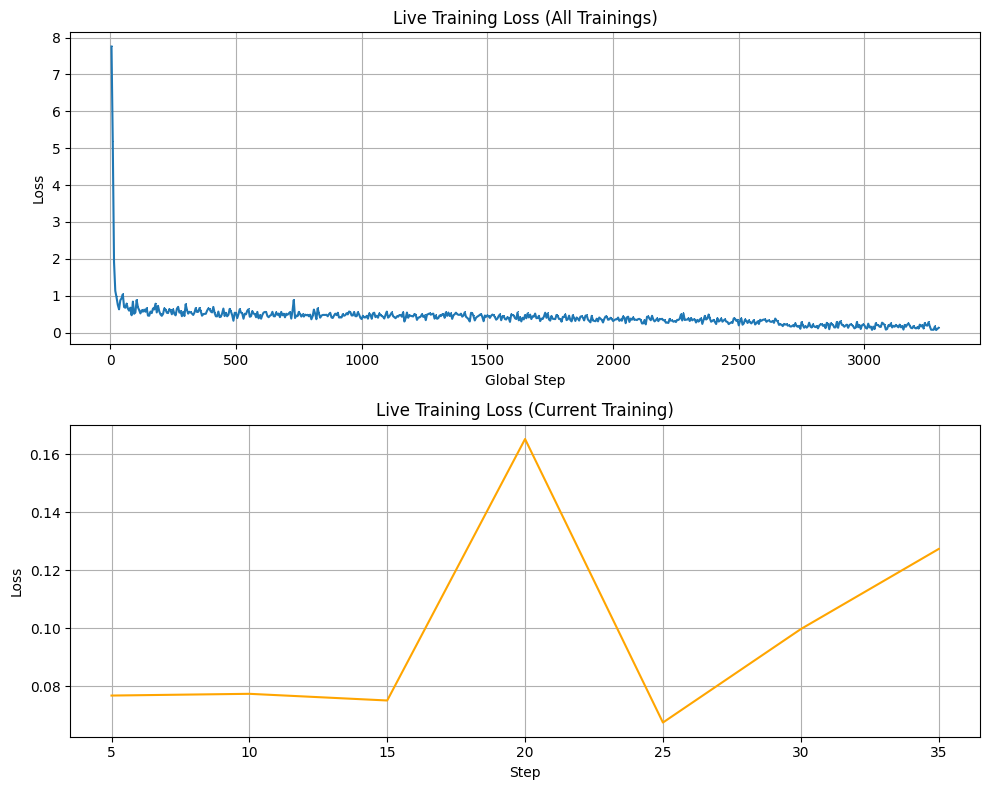

[best-lora] hf://eduhuemar001/tinyllama-german-sentiment-4bit-v6/best_lora  step=3265  loss=0.076800


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Loss log flushed to Hugging Face at step 3270


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Loss log flushed to Hugging Face at step 3280


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Loss log flushed to Hugging Face at step 3290


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


In [ ]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

HF_REPO_ID = "eduhuemar001/tinyllama-german-checkpoints-sentiment-4bit-v6"
resume_checkpoint = None

# Check if checkpoint exists
api = HfApi()
try:
    files = list_repo_files(repo_id=HF_REPO_ID, repo_type="model")
    checkpoints = [f for f in files if "checkpoint" in f]
    if checkpoints:
        print("Found checkpoint on Hugging Face Hub.")
        resume_checkpoint = HF_REPO_ID
    else:
        print("No checkpoint found.")
except Exception as e:
    print("Error checking checkpoint repo:", e)

# Train
start_time = time.time()
if resume_checkpoint:
    print(f"Resuming from HF checkpoint: {resume_checkpoint}")
    local_path = snapshot_download(
      repo_id=HF_REPO_ID,
      repo_type="model",
      local_dir="/content/hf-checkpoints",
    )

    # Resume from actual subfolder path
    resume_checkpoint = os.path.join(local_path, "last-checkpoint")
    trainer.train(resume_from_checkpoint=resume_checkpoint)
else:
    print("Starting fresh training...")
    trainer.train()
end_time = time.time()
print(f"Training took {end_time - start_time:.2f} seconds")

# Save LoRA adapter (not full model)
model.save_pretrained("tinyllama-german-lora")
tokenizer.save_pretrained("tinyllama-german-lora")

# Upload adapter only
api.upload_folder(
    folder_path="tinyllama-german-lora",
    repo_id="eduhuemar001/tinyllama-german-sentiment-4bit-v6",
    repo_type="model",
    commit_message="Uploading LoRA adapter after training."
)

# Delete HF checkpoint after successful training
try:
    print(f"Deleting checkpoint repo: {HF_REPO_ID}")
    delete_repo(repo_id=HF_REPO_ID, repo_type="model")
except Exception as e:
    print("Failed to delete checkpoint repo:", e)

# Delete dataset snapshot after successful training
try:
    print(f"Deleting checkpoint repo: eduhuemar001/tinyllama-german-checkpoints-sentiment-4bit-v6")
    delete_repo(repo_id="eduhuemar001/tinyllama-german-checkpoints-sentiment-4bit-v6", repo_type="dataset")
except Exception as e:
    print("Failed to delete checkpoint repo:", e)

In [ ]:
TRAIN_USED_PATH = "/content/train_used_dataset.json"

def export_dataset(ds, path):
    json_data = []
    with open(path, "w", encoding="utf-8") as f:
        for example in ds:
            if example["review_text"] and example["sentiment"]:
                item = {
                    "review_text": example["review_text"].strip(),
                    "sentiment": example["sentiment"].strip()
                }
                json.dump(item, f, ensure_ascii=False)
                f.write("\n")
                json_data.append(item)
    return json_data

steps_done = trainer.state.global_step
batch_size = training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps
samples_used = steps_done * batch_size
print(f"Samples used: {samples_used}")

used_dataset = export_dataset(dataset[:samples_used], TRAIN_USED_PATH)

# Upload train split
api.create_repo(repo_id=HF_DATASET_REPO_ID, repo_type="dataset", exist_ok=True, token=True)
api.upload_file(
    path_or_fileobj=TRAIN_USED_PATH,
    path_in_repo="train_used_dataset.json",
    repo_id=HF_DATASET_REPO_ID,
    repo_type="dataset",
    commit_message="Upload sentiment train split"
)

print(f"Uploaded first {samples_used} samples to hugginface")

In [ ]:
print(len(dataset))

42518


In [ ]:
print(len(used_dataset))

1600


## Appendix

#### Memory usage

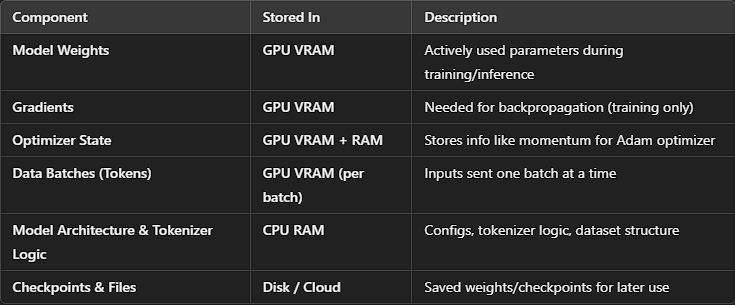